# Verification of Hyperparameter Search Setup

This notebook runs the verification step of the hyperparameter search to ensure that the default parameters produce reasonable results.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import logging
import sys
from pathlib import Path
import torch


import matplotlib.pyplot as plt
import diffmeshopt.opt2d.hyperparameter_search as hps
from diffmeshopt.opt2d.hyperparameter_search import ExperimentRunner

# Configure logging to stdout
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)

In [3]:
# Define paths
dataset_path = "../data/2d_training_data_perturbations.pkl"  # Adjust if needed
output_dir = "../output/verification_test"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

Using device: cpu


In [13]:
# Initialize Runner
runner = ExperimentRunner(dataset_path, output_dir, device=device)

2026-06-29 15:55:06,217 - INFO - Loading dataset from ../data/2d_training_data_perturbations.pkl


In [14]:
runner.device

'cpu'

In [15]:
# Run Verification
success = runner.verify_run()

if success:
    print("Verification run SUCCESSFUL.")
else:
    print("Verification run FAILED.")

2026-06-29 15:55:07,261 - INFO - Starting verification run...
2026-06-29 15:55:07,262 - INFO - Verifying on case: original
2026-06-29 15:55:07,262 - INFO - Running case: original
2026-06-29 15:55:07,263 - INFO - Parameters: {"trial_id": "verify", "refiner": "vertex", "template": "per_point", "symmetric": true, "reg_mode": "static", "num_cp": 50, "rbf_sigma": 1.0, "w_laplacian": 0.0, "w_edge": 0.0, "w_normal": 50.0, "w_tangential": 5.0, "w_shape": 1.0, "w_anchor": 0.0, "w_smooth_param": 50.0, "min_peak_ratio": 2.0}
2026-06-29 15:55:07,263 - INFO - Used params: ['refiner', 'reg_mode', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-06-29 15:55:07,264 - INFO - Unused params: ['min_peak_ratio', 'num_cp', 'rbf_sigma', 'w_shape']
2026-06-29 15:55:07,264 - INFO - Creating template model: per_point
2026-06-29 15:55:07,265 - INFO - Initializing ContourLoss
2026-06-29 15:55:07,266 - INFO - Output directory set to: ../ou

Verification run SUCCESSFUL.


In [17]:
### First test is without the tangential and normal laplacian

In [54]:
default_params = {
    "trial_id": "verify",
    "refiner": "vertex",
    "template": "global",
    "symmetric": True,
    "reg_mode": "static",
    "num_cp": 50,
    "rbf_sigma": 1.0,
    "w_laplacian": 50.0,
    "w_edge": 10.0,
    "w_normal": 0.0,
    "w_tangential": 0.0,
    # "w_normal": 50.0,
    # "w_tangential": 100.0,
    "w_shape": 1.0,
    "w_anchor": 0.0,
    "w_smooth_param": 0.0,
}


In [55]:
refiner_props, template_props, t_mode = runner._build_props(default_params)

2026-06-29 16:02:30,720 - INFO - Used params: ['refiner', 'reg_mode', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-06-29 16:02:30,721 - INFO - Unused params: ['num_cp', 'rbf_sigma', 'w_shape']


In [56]:
template_props

TemplateProps(sigma=0.75, peak_dist=4.0, min_peak_ratio=2.0, sigma_ratio=1.0, amp_ratio=1.0, symmetric=True, smoothness_window_size=3)

In [57]:
init_contour = runner.dataset["original"]["contour"]
image = runner.dataset["original"]["image"]
template_model = hps.TemplateModelFactory.create(
    t_mode,
    template_props,
    num_vertices=len(init_contour),
    image_shape=image.shape,
).to(runner.device)

2026-06-29 16:02:33,248 - INFO - Creating template model: global


In [58]:
# Prepare Tensors
image_t = torch.from_numpy(image).float().to(runner.device)
contour_t = torch.from_numpy(init_contour).float().to(runner.device)


In [59]:
refiner = hps.ContourRefiner(contour_t, refiner_props, template_model)

2026-06-29 16:02:34,217 - INFO - Initializing ContourLoss


In [60]:
refiner.to(device)

ContourRefiner(
  (template_model): GlobalOptimizableTemplateModel()
  (loss_fn): ContourLoss(
    (data_loss_fn): BiGaussianLoss()
    (laplacian_loss_fn): LaplacianSmoothingLoss()
    (edge_loss_fn): EdgeLengthConsistencyLoss()
    (spacing_loss_fn): LaplacianSmoothingLoss()
    (fairing_loss_fn): NormalConsistencyLoss()
    (shape_loss_fn): TemplateShapeLoss()
  )
)

In [61]:
run_dir = runner.output_dir / "trials" / f"verification"

config = hps.TrainerConfig(
    output_dir=run_dir,
    image=image,
    gt_contour=None,
    max_steps=2000,
    save_interval=2000,  # Only save at end
    log_interval=500,
    use_tensorboard=False,  # Disable TB to save IO
    save_images=True,
    enable_progress_bar=True,  # Disable progress bar for parallel runs
)

In [62]:
trainer = hps.OptimizationTrainer(refiner, config)

2026-06-29 16:02:35,708 - INFO - Output directory set to: ../output/verification_test/trials/verification/2026-06-29_16-02-35
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [63]:
trainer.fit(2000)

2026-06-29 16:02:36,391 - INFO - Starting fit for 2000 steps.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/saugat/code/diffmeshopt/output/verification_test/trials/verification/2026-06-29_16-02-35 exists and is not empty.


Epoch 0: 100%|#| 2000/2000 [00:07<00:00, 268.47it/s, v_num=1.0, total_loss=1.03]

`Trainer.fit` stopped: `max_steps=2000` reached.


2026-06-29 16:02:43,847 - INFO - Final state saved to ../output/verification_test/trials/verification/2026-06-29_16-02-35/final.pkl


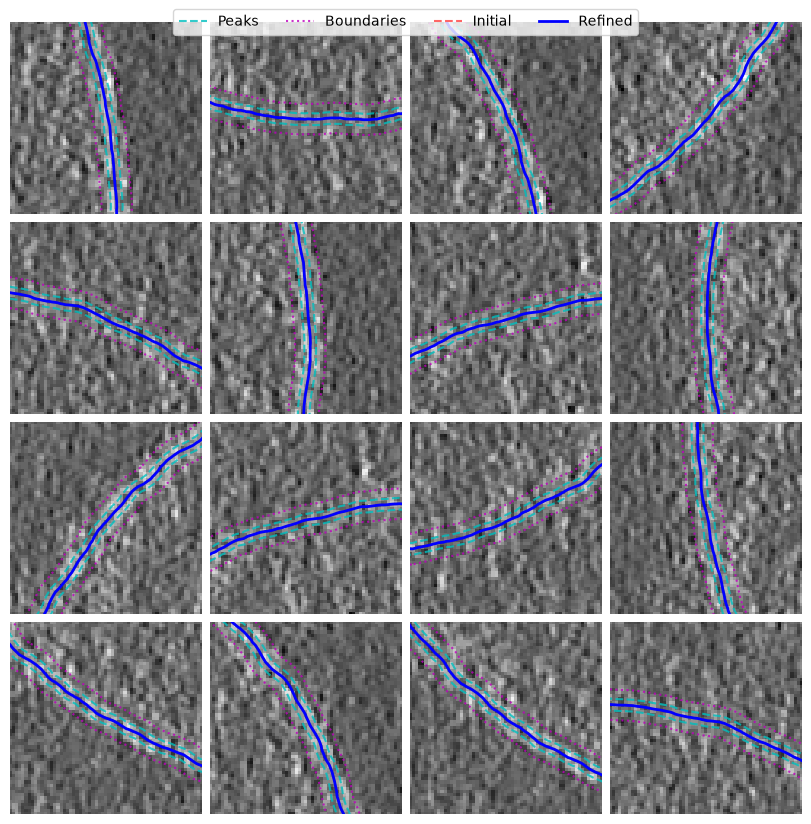

In [64]:
trainer.plot_image()

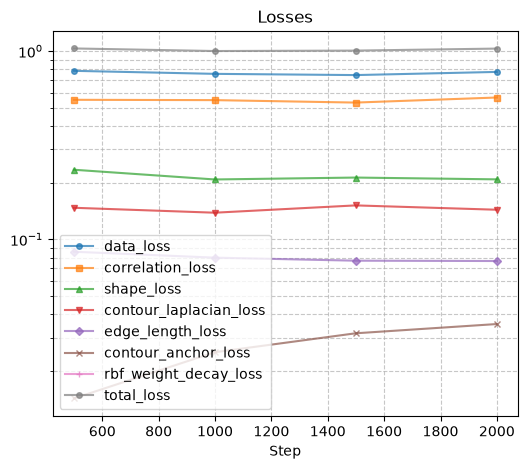

In [65]:
trainer.plot_metrics()

In [66]:
# Evaluate
final_contour = refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics = hps.compute_contour_metrics(refiner.contour, contour_t)
chamfer = metrics["mean_dist"]

In [67]:
metrics["mean_dist"]

0.5938761234283447

In [68]:
template_params = trainer.refiner.template_model.get_params()
template_params


{'peak_dist': tensor(3.6757, grad_fn=<MulBackward0>),
 'sigma1': tensor(1.4630, grad_fn=<ExpBackward0>),
 'sigma2': tensor(1.4630, grad_fn=<ExpBackward0>),
 'amp1': tensor(1.),
 'amp2': tensor(1.)}

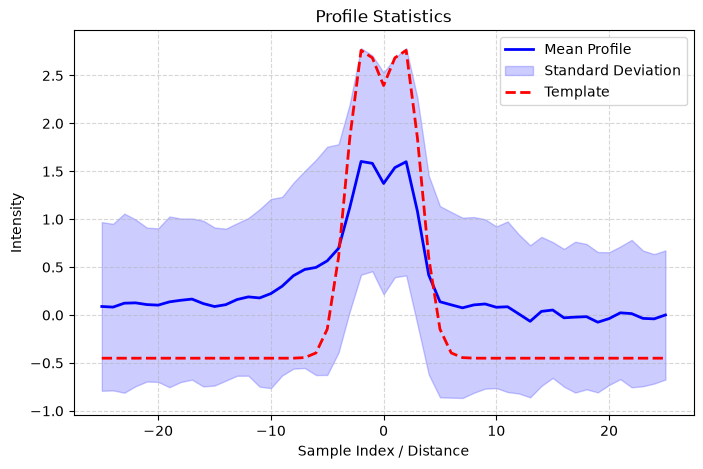

In [69]:
refiner.visualize_profile_statistics(image_t.cpu())

In [74]:
## Verifying a per-vertex template with laplacian and edge-based smoothing.

In [75]:
default_params = {
    "trial_id": "verify",
    "refiner": "vertex",
    "template": "per_point",
    "symmetric": True,
    "reg_mode": "static",
    "num_cp": 50,
    "rbf_sigma": 1.0,
    "w_laplacian": 50.0,
    "w_edge": 10.0,
    "w_normal": 0.0,
    "w_tangential": 0.0,
    # "w_normal": 50.0,
    # "w_tangential": 100.0,
    "w_shape": 1.0,
    "w_anchor": 0.0,
    "w_smooth_param": 50.0,
    "min_peak_ratio": 2.0,
}


In [76]:
refiner_props, template_props, t_mode = runner._build_props(default_params)

2026-06-29 16:05:01,036 - INFO - Used params: ['refiner', 'reg_mode', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-06-29 16:05:01,036 - INFO - Unused params: ['min_peak_ratio', 'num_cp', 'rbf_sigma', 'w_shape']


In [77]:
template_props

TemplateProps(sigma=0.75, peak_dist=4.0, min_peak_ratio=2.0, sigma_ratio=1.0, amp_ratio=1.0, symmetric=True, smoothness_window_size=3)

In [78]:
init_contour = runner.dataset["original"]["contour"]
image = runner.dataset["original"]["image"]
template_model = hps.TemplateModelFactory.create(
    t_mode,
    template_props,
    num_vertices=len(init_contour),
    image_shape=image.shape,
).to(runner.device)

2026-06-29 16:05:01,629 - INFO - Creating template model: per_point


In [79]:
# Prepare Tensors
image_t = torch.from_numpy(image).float().to(runner.device)
contour_t = torch.from_numpy(init_contour).float().to(runner.device)


In [80]:
refiner = hps.ContourRefiner(contour_t, refiner_props, template_model)

2026-06-29 16:05:02,311 - INFO - Initializing ContourLoss


In [81]:
refiner.to(device)

ContourRefiner(
  (template_model): PerPointTemplateModel(
    (laplacian_loss_fn): LaplacianSmoothingLoss()
  )
  (loss_fn): ContourLoss(
    (data_loss_fn): BiGaussianLoss()
    (laplacian_loss_fn): LaplacianSmoothingLoss()
    (edge_loss_fn): EdgeLengthConsistencyLoss()
    (spacing_loss_fn): LaplacianSmoothingLoss()
    (fairing_loss_fn): NormalConsistencyLoss()
    (shape_loss_fn): TemplateShapeLoss()
  )
)

In [82]:
run_dir = runner.output_dir / "trials" / f"verification"

config = hps.TrainerConfig(
    output_dir=run_dir,
    image=image,
    gt_contour=None,
    max_steps=2000,
    save_interval=2000,  # Only save at end
    log_interval=500,
    use_tensorboard=False,  # Disable TB to save IO
    save_images=True,
    enable_progress_bar=True,  # Disable progress bar for parallel runs
)

In [83]:
trainer = hps.OptimizationTrainer(refiner, config)

2026-06-29 16:05:03,733 - INFO - Output directory set to: ../output/verification_test/trials/verification/2026-06-29_16-05-03
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [84]:
trainer.fit(2000)

2026-06-29 16:05:04,104 - INFO - Starting fit for 2000 steps.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/saugat/code/diffmeshopt/output/verification_test/trials/verification/2026-06-29_16-05-03 exists and is not empty.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 0: 100%|#| 2000/2000 [00:08<00:00, 228.89it/s, v_num=1.0, total_loss=0.994

`Trainer.fit` stopped: `max_steps=2000` reached.


2026-06-29 16:05:12,849 - INFO - Final state saved to ../output/verification_test/trials/verification/2026-06-29_16-05-03/final.pkl


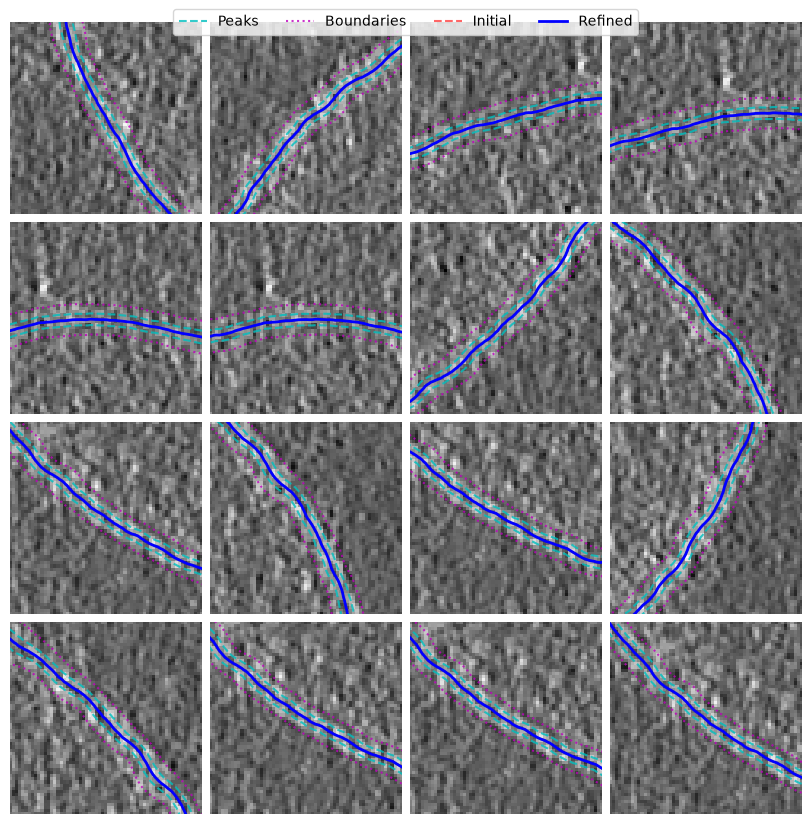

In [85]:
trainer.plot_image()

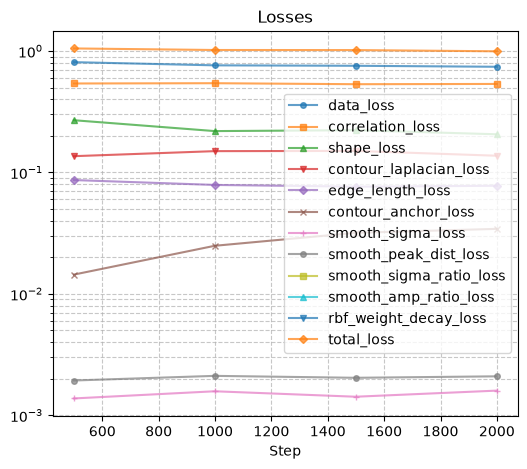

In [86]:
trainer.plot_metrics()

In [87]:
# Evaluate
final_contour = refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics = hps.compute_contour_metrics(refiner.contour, contour_t)
chamfer = metrics["mean_dist"]
chamfer

0.5880472660064697

In [88]:
metrics["mean_dist"]

0.5880472660064697

In [89]:
template_params = trainer.refiner.template_model.get_params()
template_params


{'peak_dist': tensor([3.6038, 3.6100, 3.6456,  ..., 3.5945, 3.5851, 3.5547],
        grad_fn=<MulBackward0>),
 'sigma1': tensor([1.4328, 1.4150, 1.4205,  ..., 1.4721, 1.4584, 1.4342],
        grad_fn=<ExpBackward0>),
 'sigma2': tensor([1.4328, 1.4150, 1.4205,  ..., 1.4721, 1.4584, 1.4342],
        grad_fn=<ExpBackward0>),
 'amp1': tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 'amp2': tensor([1., 1., 1.,  ..., 1., 1., 1.])}

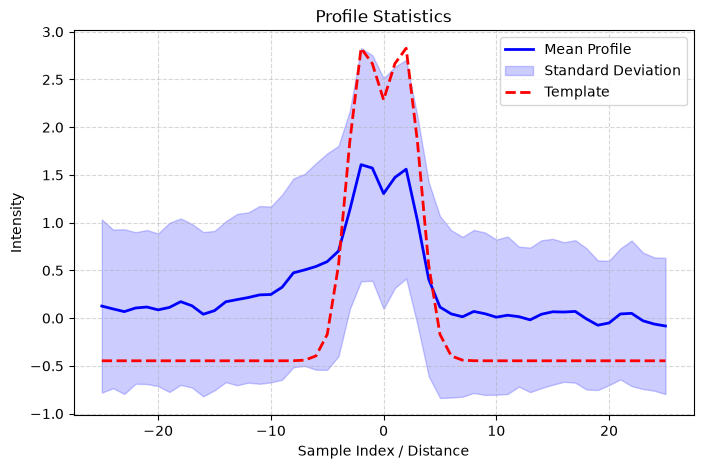

In [90]:
refiner.visualize_profile_statistics(image_t.cpu())

In [97]:
template_props

TemplateProps(sigma=0.75, peak_dist=4.0, min_peak_ratio=2.0, sigma_ratio=1.0, amp_ratio=1.0, symmetric=True, smoothness_window_size=3)

Mean Peak Dist: 3.70, Mean Sigma1: 1.42, Mean Sigma2: 1.42
Original Peak Dist: 4.0 Original Sigma1: 0.75


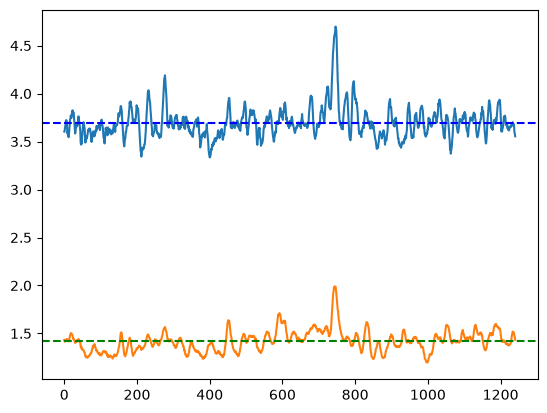

In [100]:
mean_peak_dist = template_params["peak_dist"].detach().numpy().mean()
mean_sigma1 = template_params["sigma1"].detach().numpy().mean()
mean_sigma2 = template_params["sigma2"].detach().numpy().mean()

print(
    f"Mean Peak Dist: {mean_peak_dist:.2f}, Mean Sigma1: {mean_sigma1:.2f}, Mean Sigma2: {mean_sigma2:.2f}"
)
print(f"Original Peak Dist: {template_props.peak_dist} Original Sigma1: {template_props.sigma}")

plt.plot(template_params["peak_dist"].detach().numpy())
plt.plot(template_params["sigma1"].detach().numpy())
plt.axhline(
    y=mean_peak_dist,
    color="b",
    linestyle="dashed",
)
plt.axhline(
    y=mean_sigma1,
    color="g",
    linestyle="dashed",
)
plt.show()

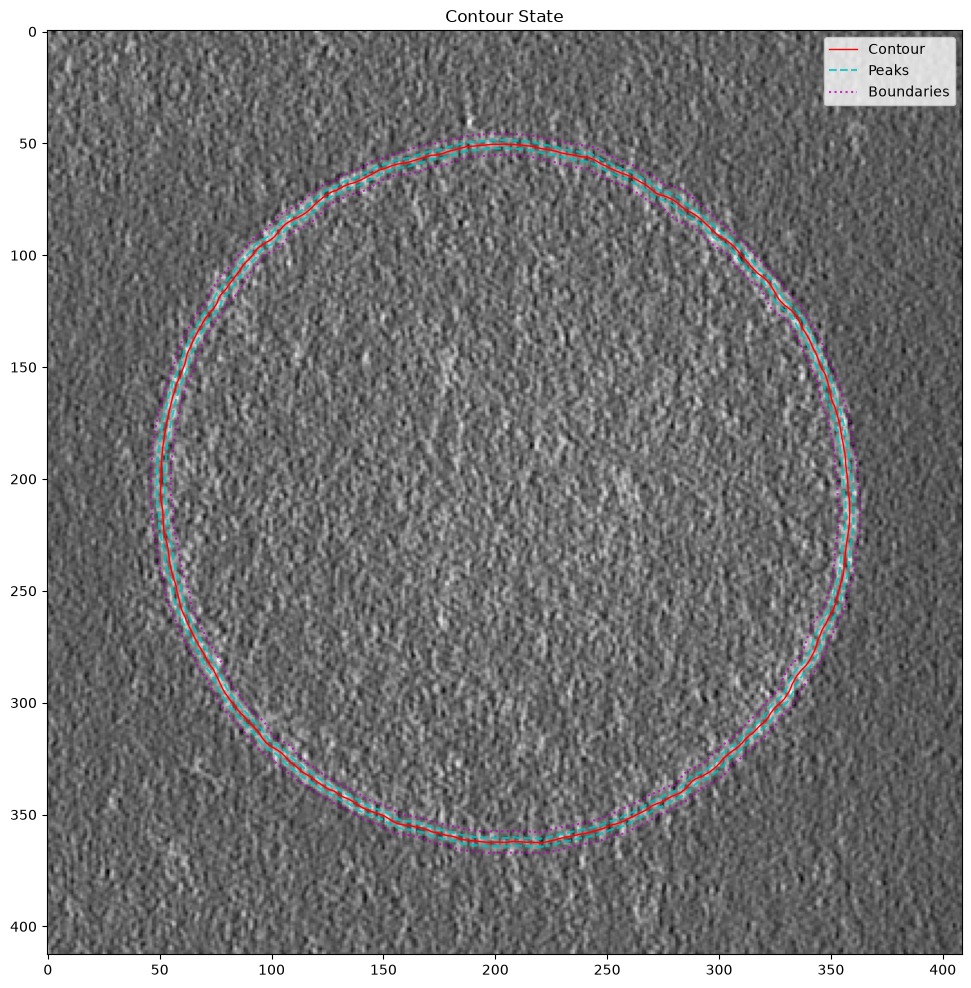

In [101]:
trainer.refiner.visualize_contour(image_t.detach())

In [102]:
## Verifying a per-vertex template with tangential and normal smoothing.

In [103]:
default_params = {
    "trial_id": "verify",
    "refiner": "vertex",
    "template": "per_point",
    "symmetric": True,
    "reg_mode": "static",
    "num_cp": 50,
    "rbf_sigma": 1.0,
    "w_laplacian": 0.0,
    "w_edge": 0.0,
    "w_normal": 50.0,
    "w_tangential": 5.0,
    "w_shape": 1.0,
    "w_anchor": 0.0,
    "w_smooth_param": 50.0,
    "min_peak_ratio": 2.0,
}


In [104]:
refiner_props, template_props, t_mode = runner._build_props(default_params)

2026-06-29 16:09:36,510 - INFO - Used params: ['refiner', 'reg_mode', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-06-29 16:09:36,513 - INFO - Unused params: ['min_peak_ratio', 'num_cp', 'rbf_sigma', 'w_shape']


In [105]:
template_props

TemplateProps(sigma=0.75, peak_dist=4.0, min_peak_ratio=2.0, sigma_ratio=1.0, amp_ratio=1.0, symmetric=True, smoothness_window_size=3)

In [106]:
init_contour = runner.dataset["original"]["contour"]
image = runner.dataset["original"]["image"]
template_model = hps.TemplateModelFactory.create(
    t_mode,
    template_props,
    num_vertices=len(init_contour),
    image_shape=image.shape,
).to(runner.device)

2026-06-29 16:09:37,808 - INFO - Creating template model: per_point


In [107]:
# Prepare Tensors
image_t = torch.from_numpy(image).float().to(runner.device)
contour_t = torch.from_numpy(init_contour).float().to(runner.device)


In [108]:
refiner = hps.ContourRefiner(contour_t, refiner_props, template_model)

2026-06-29 16:09:38,816 - INFO - Initializing ContourLoss


In [109]:
refiner.to(device)

ContourRefiner(
  (template_model): PerPointTemplateModel(
    (laplacian_loss_fn): LaplacianSmoothingLoss()
  )
  (loss_fn): ContourLoss(
    (data_loss_fn): BiGaussianLoss()
    (laplacian_loss_fn): LaplacianSmoothingLoss()
    (edge_loss_fn): EdgeLengthConsistencyLoss()
    (spacing_loss_fn): LaplacianSmoothingLoss()
    (fairing_loss_fn): NormalConsistencyLoss()
    (shape_loss_fn): TemplateShapeLoss()
  )
)

In [110]:
run_dir = runner.output_dir / "trials" / f"verification"

config = hps.TrainerConfig(
    output_dir=run_dir,
    image=image,
    gt_contour=None,
    max_steps=2000,
    save_interval=2000,  # Only save at end
    log_interval=500,
    use_tensorboard=False,  # Disable TB to save IO
    save_images=True,
    enable_progress_bar=True,  # Disable progress bar for parallel runs
)

In [111]:
trainer = hps.OptimizationTrainer(refiner, config)

2026-06-29 16:09:41,300 - INFO - Output directory set to: ../output/verification_test/trials/verification/2026-06-29_16-09-41
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [112]:
trainer.fit(2000)

2026-06-29 16:09:42,195 - INFO - Starting fit for 2000 steps.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/saugat/code/diffmeshopt/output/verification_test/trials/verification/2026-06-29_16-09-41 exists and is not empty.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 0: 100%|#| 2000/2000 [00:09<00:00, 205.76it/s, v_num=1.0, total_loss=0.87]

`Trainer.fit` stopped: `max_steps=2000` reached.


2026-06-29 16:09:51,923 - INFO - Final state saved to ../output/verification_test/trials/verification/2026-06-29_16-09-41/final.pkl


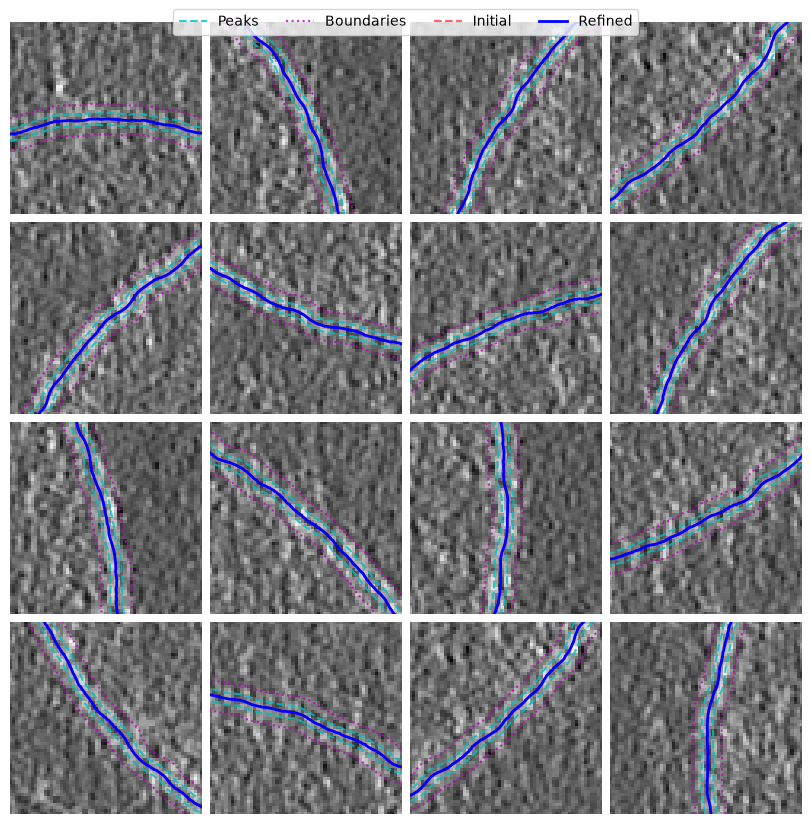

In [113]:
trainer.plot_image()

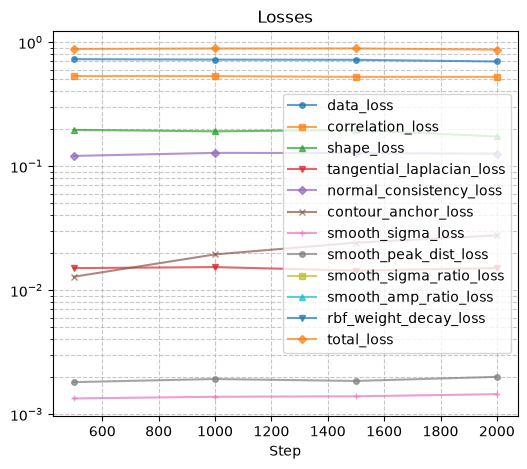

In [114]:
trainer.plot_metrics()

In [115]:
# Evaluate
final_contour = refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics = hps.compute_contour_metrics(refiner.contour, contour_t)
chamfer = metrics["mean_dist"]
chamfer

0.5933065414428711

In [116]:
template_params = trainer.refiner.template_model.get_params()
template_params


{'peak_dist': tensor([3.6348, 3.6217, 3.7089,  ..., 3.6407, 3.5845, 3.6057],
        grad_fn=<MulBackward0>),
 'sigma1': tensor([1.4603, 1.4361, 1.4577,  ..., 1.4697, 1.4514, 1.4591],
        grad_fn=<ExpBackward0>),
 'sigma2': tensor([1.4603, 1.4361, 1.4577,  ..., 1.4697, 1.4514, 1.4591],
        grad_fn=<ExpBackward0>),
 'amp1': tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 'amp2': tensor([1., 1., 1.,  ..., 1., 1., 1.])}

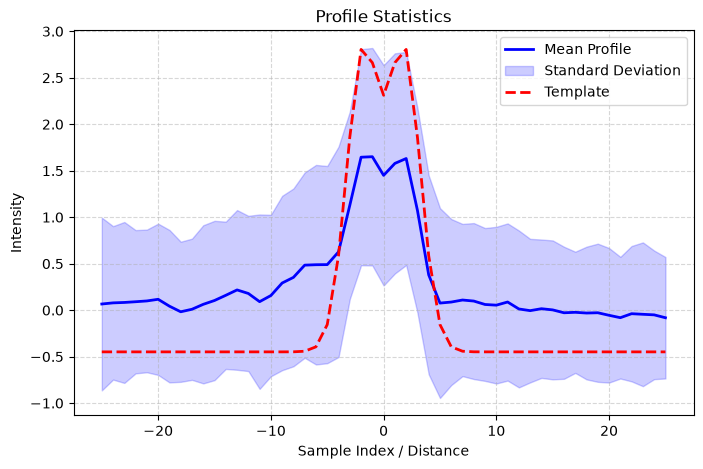

In [117]:
refiner.visualize_profile_statistics(image_t.cpu())

Mean Peak Dist: 3.71, Mean Sigma1: 1.44, Mean Sigma2: 1.44
Original Peak Dist: 4.0 Original Sigma1: 0.75


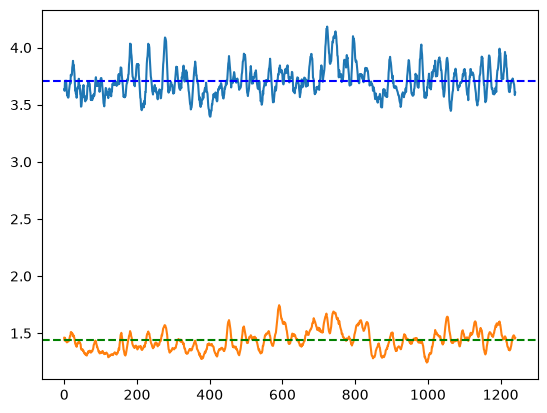

In [118]:
mean_peak_dist = template_params["peak_dist"].detach().numpy().mean()
mean_sigma1 = template_params["sigma1"].detach().numpy().mean()
mean_sigma2 = template_params["sigma2"].detach().numpy().mean()

print(
    f"Mean Peak Dist: {mean_peak_dist:.2f}, Mean Sigma1: {mean_sigma1:.2f}, Mean Sigma2: {mean_sigma2:.2f}"
)
print(f"Original Peak Dist: {template_props.peak_dist} Original Sigma1: {template_props.sigma}")

plt.plot(template_params["peak_dist"].detach().numpy())
plt.plot(template_params["sigma1"].detach().numpy())
plt.axhline(
    y=mean_peak_dist,
    color="b",
    linestyle="dashed",
)
plt.axhline(
    y=mean_sigma1,
    color="g",
    linestyle="dashed",
)
plt.show()

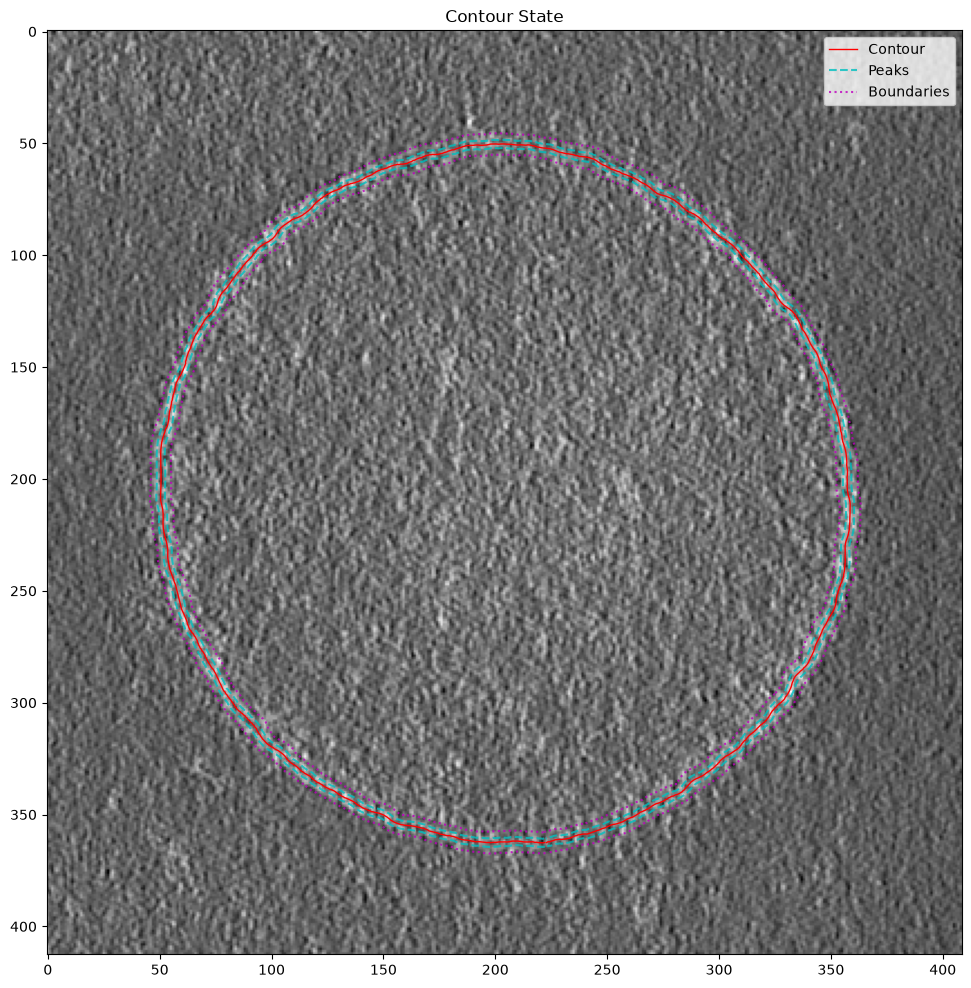

In [119]:
trainer.refiner.visualize_contour(image_t.detach())